In [15]:
from ds.eval.inference_mrcnn import get_xform
from ds.datasets.db_improc import process_read_srh  
import matplotlib.pyplot as plt
import einops
from torchvision.transforms.functional import adjust_contrast, adjust_brightness
import torch

In [13]:
normalize_im = lambda x: (adjust_brightness(adjust_contrast(x, 2), 2) * 255     
                     ).to(torch.uint8)                         

In [22]:
xf = get_xform(subtracted_base=5000)

In [23]:
im = xf(process_read_srh("/nfs/turbo/umms-tocho/root_srh_db/UCSF/NIO_UCSF_18179/11/patches/NIO_UCSF_18179-11-1000_1000_300_300.tif"), {})

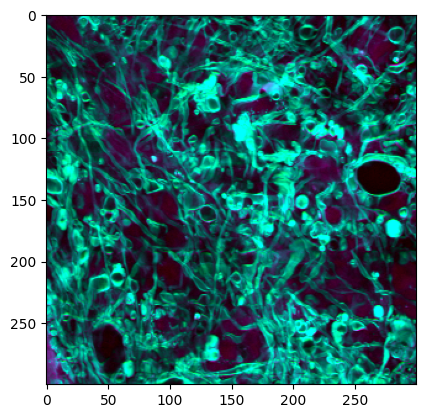

In [24]:
plt.imshow(einops.rearrange(normalize_im(im[0]), "c h w -> h w c"))


In [32]:
from PIL import Image
import numpy as np

In [27]:
Image.fromarray(einops.rearrange(normalize_im(im[0]), "c h w -> h w c").numpy()).save("test_cdet.png")

In [29]:
!ls /nfs/turbo/umms-tocho/code/chengjia/torchsrh2/ts2/playgrounds/test_cdet.png

/nfs/turbo/umms-tocho/code/chengjia/torchsrh2/ts2/playgrounds/test_cdet.png


In [42]:
test = np.load("/nfs/turbo/umms-tocho/code/chengjia/torchsrh2/ts2/playgrounds/test_cdet.png.r2d2")

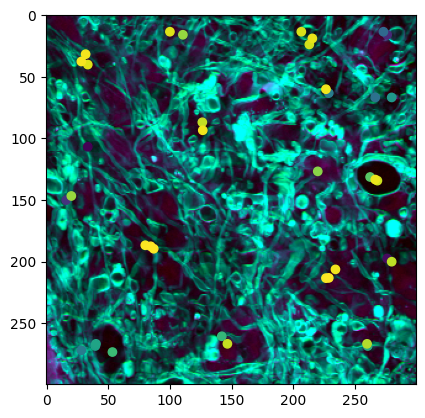

In [43]:
plt.imshow(einops.rearrange(normalize_im(im[0]), "c h w -> h w c"))
plt.scatter(test["keypoints"][:,0], test["keypoints"][:,1], c=test["scores"])

In [44]:
test["keypoints"]

array([[ 33.333336, 106.66667 , 215.26949 ],
       [276.3158  , 197.36842 , 256.      ],
       [276.3158  ,  15.789474, 256.      ],
       [ 15.789474, 150.      , 256.      ],
       [273.33334 ,  13.333334, 215.26949 ],
       [266.6667  ,  66.66667 , 215.26949 ],
       [ 28.125   , 271.875   , 304.437   ],
       [228.94737 ,  63.157894, 256.      ],
       [280.      ,  66.66667 , 215.26949 ],
       [ 39.473686, 268.42105 , 256.      ],
       [ 40.      , 266.6667  , 215.26949 ],
       [260.5263  , 268.42105 , 256.      ],
       [142.10527 , 260.5263  , 256.      ],
       [ 53.333336, 273.33334 , 215.26949 ],
       [262.5     , 131.25    , 304.437   ],
       [220.      , 126.66667 , 215.26949 ],
       [110.52631 ,  15.789474, 256.      ],
       [ 20.      , 146.66667 , 215.26949 ],
       [260.      , 266.6667  , 215.26949 ],
       [280.      , 200.      , 215.26949 ],
       [126.31579 ,  86.84211 , 256.      ],
       [146.66667 , 266.6667  , 215.26949 ],
       [26